In [ ]:
%pip install pandas numpy matplotlib seaborn plotly scikit-learn catboost lightgbm xgboost

In [76]:
# =========================================================
#                FRAUD DETECTION PROJECT
# =========================================================

# =========================
# Core Libraries
# =========================
import os
import gc
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

# =========================
# Visualization Libraries
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

# =========================
# Machine Learning - sklearn
# =========================
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn import svm

# =========================
# Gradient Boosting Models
# =========================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# =========================
# Global Configuration
# =========================
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALID_SIZE = 0.20
NUMBER_KFOLDS = 5

# Random Forest Config
RFC_METRIC = "gini"
NUM_ESTIMATORS = 200
NO_JOBS = -1

# Boosting Config
MAX_ROUNDS = 1000
EARLY_STOP = 50
VERBOSE_EVAL = 50

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [77]:
from pathlib import Path

DATA_PATH = Path("dataset") / "creditcard.csv"
data_df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape → {data_df.shape}")


Dataset Shape → (284807, 31)


In [78]:
data_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [79]:
# Missing value analysis
missing_counts = data_df.isnull().sum()
missing_percent = (missing_counts / len(data_df)) * 100

missing_df = pd.DataFrame({
    "Total Missing": missing_counts,
    "Percent Missing": missing_percent
}).sort_values(by="Total Missing", ascending=False)

missing_df = missing_df[missing_df["Total Missing"] > 0]

missing_df


,Total Missing,Percent Missing


In [80]:
# =========================
# Class Distribution
# =========================

class_counts = data_df["Class"].value_counts().sort_index()

fig = go.Figure(
    data=[
        go.Bar(
            x=class_counts.index,
            y=class_counts.values,
            text=class_counts.values,
            textposition="outside"
        )
    ]
)

fig.update_layout(
    title="Class Distribution (0 = Not Fraud, 1 = Fraud)",
    xaxis_title="Class",
    yaxis_title="Number of Transactions",
    width=700
)

iplot(fig)


In [81]:
# =========================
# Time Distribution by Class
# =========================

time_not_fraud = data_df[data_df["Class"] == 0]["Time"]
time_fraud = data_df[data_df["Class"] == 1]["Time"]

hist_data = [time_not_fraud, time_fraud]
group_labels = ["Not Fraud", "Fraud"]

fig = ff.create_distplot(
    hist_data,
    group_labels,
    show_hist=False,
    show_rug=False
)

fig.update_layout(
    title="Transaction Time Density (Fraud vs Non-Fraud)",
    xaxis_title="Time (seconds)",
    yaxis_title="Density"
)

iplot(fig)


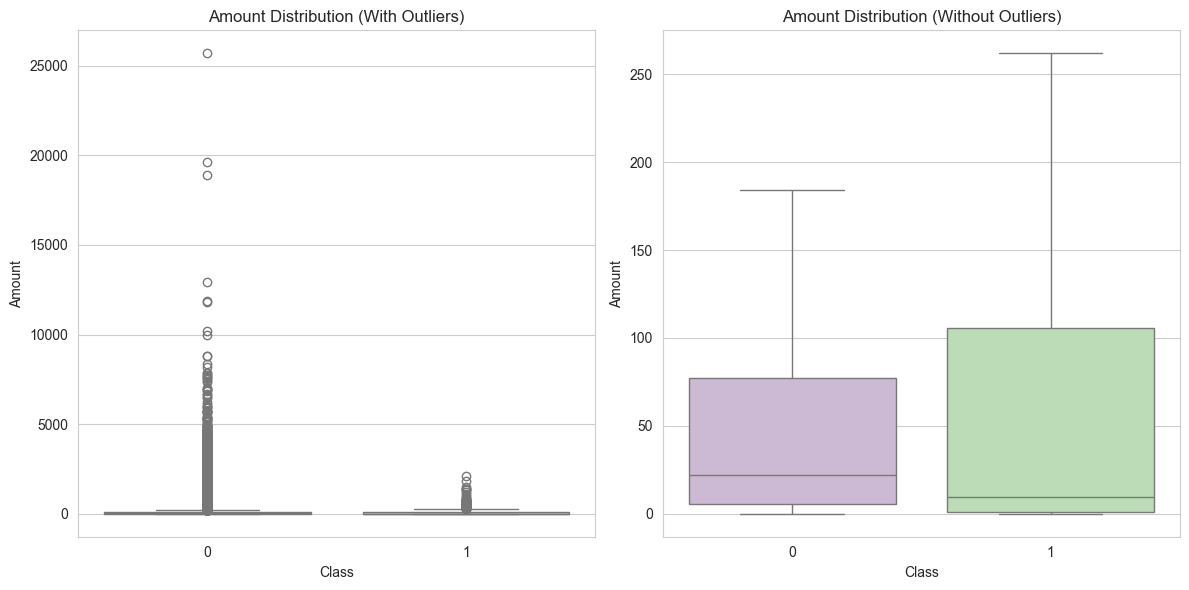

In [82]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

# With outliers
sns.boxplot(
    ax=axes[0],
    x="Class",
    y="Amount",
    hue="Class",
    data=data_df,
    palette="PRGn",
    showfliers=True,
    legend=False
)
axes[0].set_title("Amount Distribution (With Outliers)")

# Without outliers
sns.boxplot(
    ax=axes[1],
    x="Class",
    y="Amount",
    hue="Class",
    data=data_df,
    palette="PRGn",
    showfliers=False,
    legend=False
)
axes[1].set_title("Amount Distribution (Without Outliers)")

plt.tight_layout()
plt.show()


In [83]:
# =========================
# Amount Statistics by Class
# =========================

amount_stats = data_df.groupby("Class")["Amount"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
)

print(amount_stats)


        count        mean  median         std  min       max
Class                                                       
0      284315   88.291022   22.00  250.105092  0.0  25691.16
1         492  122.211321    9.25  256.683288  0.0   2125.87


In [84]:
data_df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [85]:
# =========================
# Fraud Transactions: Time vs Amount
# =========================

fraud = data_df[data_df["Class"] == 1]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=fraud["Time"],
        y=fraud["Amount"],
        mode="markers",
        marker=dict(
            color="red",
            size=6,
            opacity=0.5
        ),
        name="Fraud Transactions"
    )
)

fig.update_layout(
    title="Fraud Transactions: Amount vs Time",
    xaxis_title="Time (seconds)",
    yaxis_title="Transaction Amount",
    hovermode="closest"
)

iplot(fig)


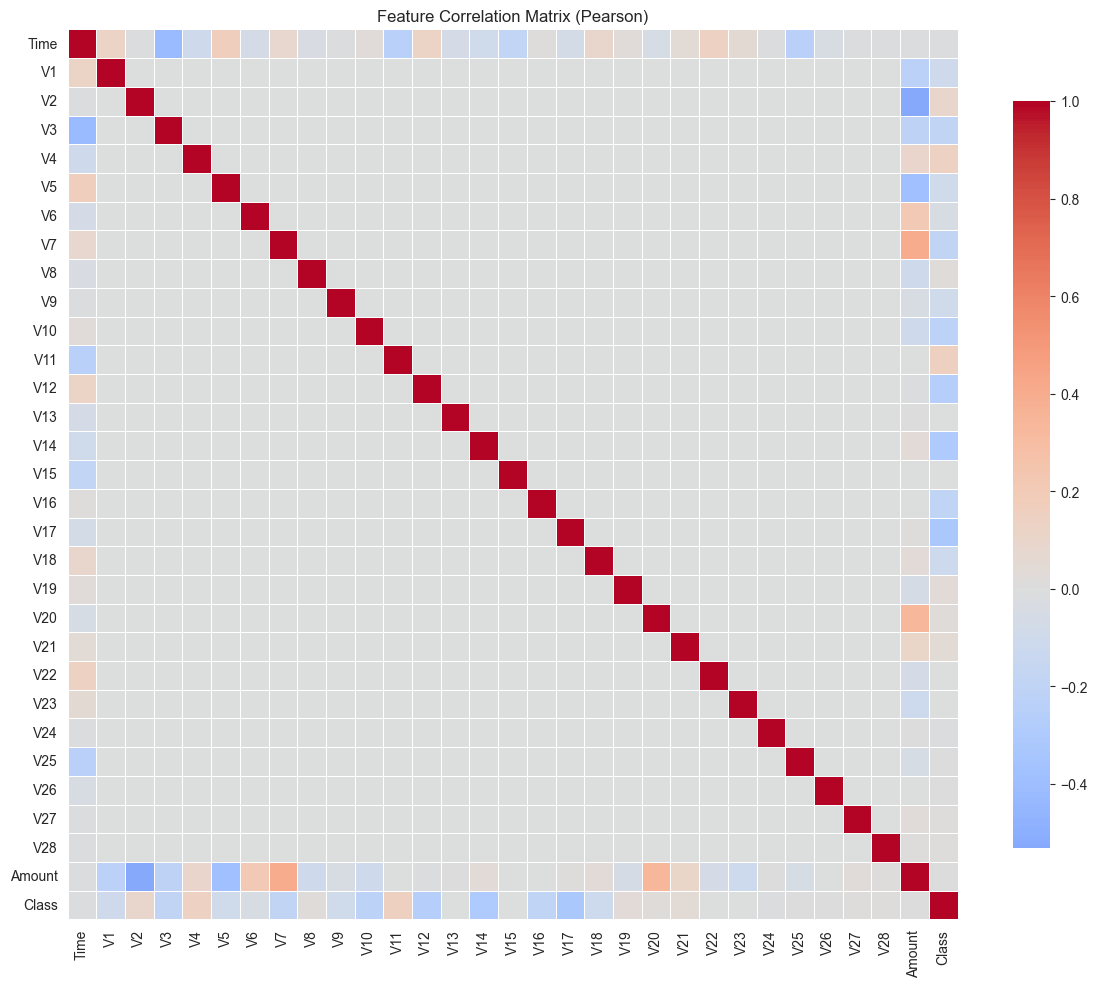

In [86]:
plt.figure(figsize=(12,10))

corr = data_df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Matrix (Pearson)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


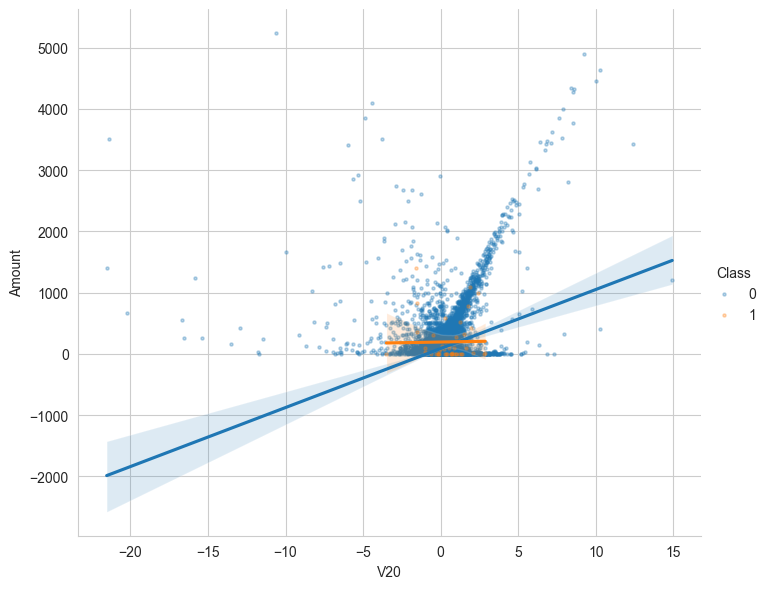

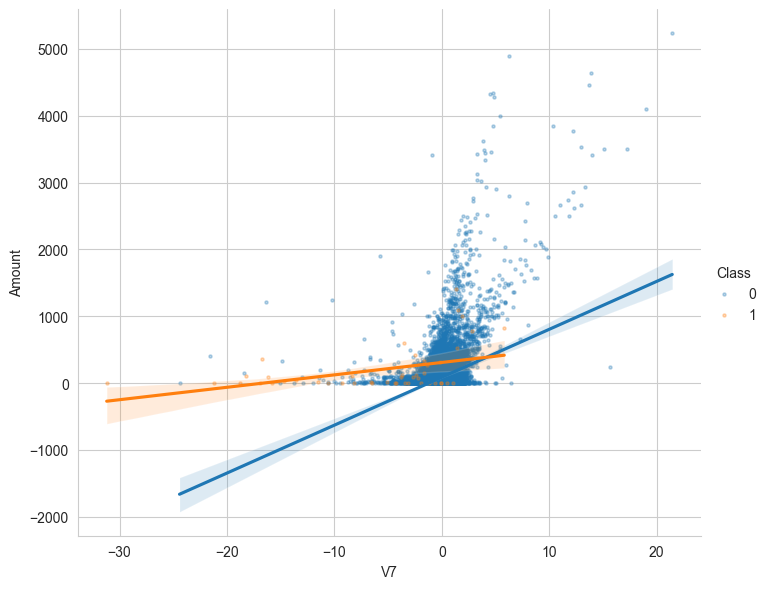

In [87]:
# Optional: downsample for visualization efficiency
sample_df = data_df.sample(frac=0.1, random_state=42)

sns.lmplot(
    x="V20",
    y="Amount",
    data=sample_df,
    hue="Class",
    fit_reg=True,
    scatter_kws={"s": 5, "alpha": 0.3},
    height=6,
    aspect=1.2
)

sns.lmplot(
    x="V7",
    y="Amount",
    data=sample_df,
    hue="Class",
    fit_reg=True,
    scatter_kws={"s": 5, "alpha": 0.3},
    height=6,
    aspect=1.2
)

plt.show()


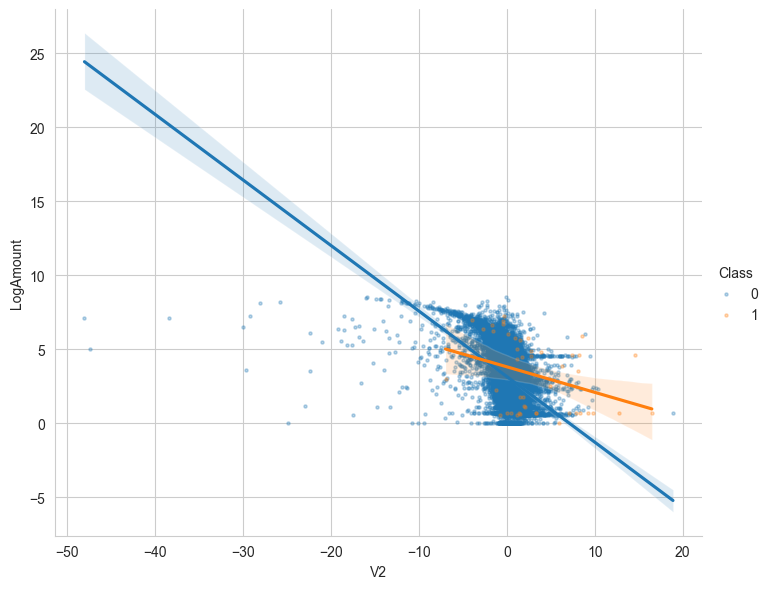

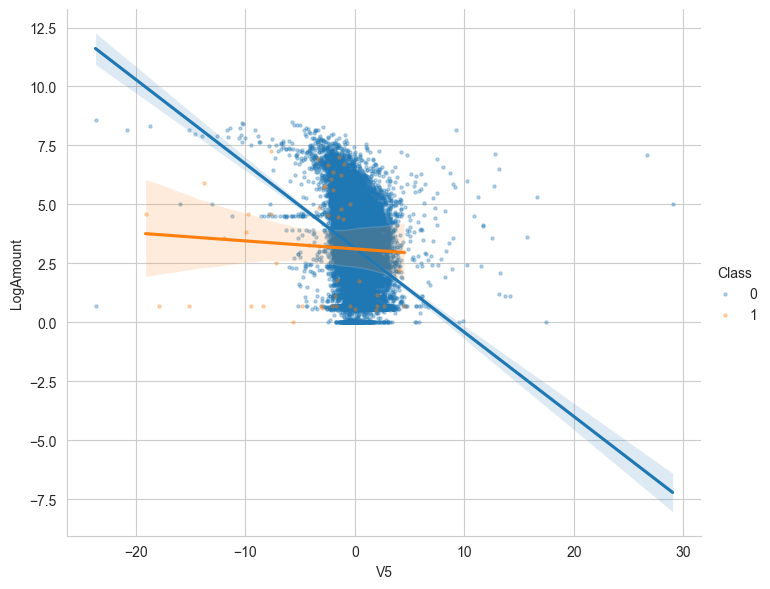

In [88]:
# Downsample for visualization (10%)
sample_df = data_df.sample(frac=0.1, random_state=42)

# Log-transform Amount to reduce skew
sample_df["LogAmount"] = np.log1p(sample_df["Amount"])

sns.lmplot(
    x="V2",
    y="LogAmount",
    data=sample_df,
    hue="Class",
    fit_reg=True,
    scatter_kws={"s": 5, "alpha": 0.3},
    height=6,
    aspect=1.2
)

sns.lmplot(
    x="V5",
    y="LogAmount",
    data=sample_df,
    hue="Class",
    fit_reg=True,
    scatter_kws={"s": 5, "alpha": 0.3},
    height=6,
    aspect=1.2
)

plt.show()


In [89]:
target = "Class"

predictors = [
    'Time','V1','V2','V3','V4','V5','V6','V7','V8','V9','V10',
    'V11','V12','V13','V14','V15','V16','V17','V18','V19',
    'V20','V21','V22','V23','V24','V25','V26','V27','V28','Amount'
]

In [90]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp (valid + test)
train_df, temp_df = train_test_split(
    data_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=data_df["Class"]
)

# Second split: Validation + Test
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=temp_df["Class"]
)


In [91]:
print("Train fraud ratio:", train_df["Class"].mean())
print("Valid fraud ratio:", valid_df["Class"].mean())
print("Test fraud ratio:", test_df["Class"].mean())

Train fraud ratio: 0.001729245759178389
Valid fraud ratio: 0.0017204452090867595
Test fraud ratio: 0.0017204452090867595


In [92]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

X_train = train_df[predictors]
y_train = train_df[target]

X_valid = valid_df[predictors]
y_valid = valid_df[target]

clf = RandomForestClassifier(
    n_estimators=NUM_ESTIMATORS,
    criterion=RFC_METRIC,
    random_state=RANDOM_STATE,
    n_jobs=NO_JOBS,
    class_weight="balanced",
    verbose=0
)

clf.fit(X_train, y_train)

y_valid_proba = clf.predict_proba(X_valid)[:, 1]
y_valid_pred = clf.predict(X_valid)

print("ROC-AUC:", roc_auc_score(y_valid, y_valid_proba))
print("PR-AUC:", average_precision_score(y_valid, y_valid_proba))
print(classification_report(y_valid, y_valid_pred))


ROC-AUC: 0.9363946056756974
PR-AUC: 0.8550913079370349
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.97      0.71      0.82        49

    accuracy                           1.00     28481
   macro avg       0.99      0.86      0.91     28481
weighted avg       1.00      1.00      1.00     28481



In [93]:
clf.fit(train_df[predictors], train_df[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [94]:
preds = clf.predict(valid_df[predictors])

In [95]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score
)

# 1. Confusion Matrix
cm = confusion_matrix(valid_df[target], preds)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(valid_df[target], preds))

# 2. Get probabilities (IMPORTANT for ROC & PR)
pred_proba = clf.predict_proba(valid_df[predictors])[:, 1]

# 3. Proper ROC-AUC
print("ROC-AUC (correct):", roc_auc_score(valid_df[target], pred_proba))

# 4. Precision-Recall AUC
print("PR-AUC:", average_precision_score(valid_df[target], pred_proba))

# 5. Custom threshold example (0.2)
threshold = 0.2
custom_preds = (pred_proba >= threshold).astype(int)

print("\nThreshold = 0.2")
print("Precision:", precision_score(valid_df[target], custom_preds))
print("Recall:", recall_score(valid_df[target], custom_preds))


Confusion Matrix:
 [[28431     1]
 [   14    35]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.97      0.71      0.82        49

    accuracy                           1.00     28481
   macro avg       0.99      0.86      0.91     28481
weighted avg       1.00      1.00      1.00     28481

ROC-AUC (correct): 0.9363946056756974
PR-AUC: 0.8550913079370349

Threshold = 0.2
Precision: 0.851063829787234
Recall: 0.8163265306122449


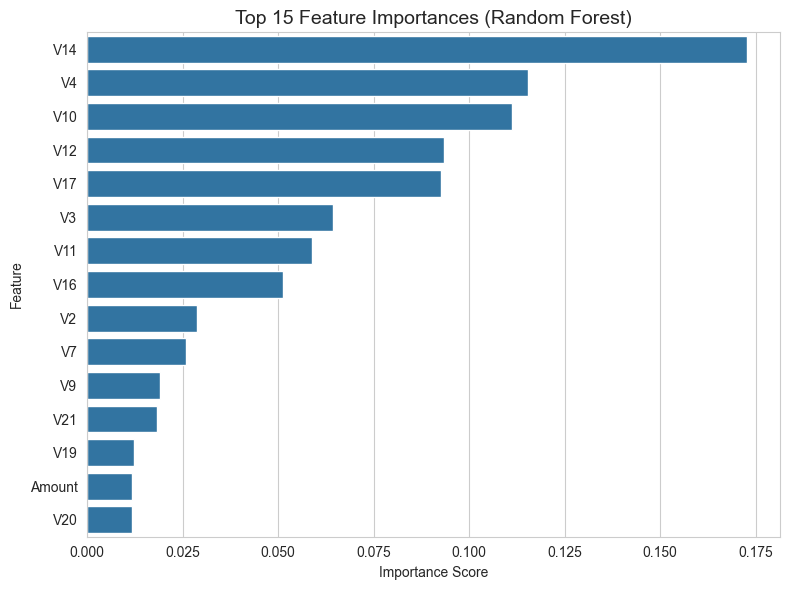

In [96]:
# Create importance dataframe
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tmp = pd.DataFrame({
    "Feature": predictors,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot Top 15 features (clean horizontal layout)
plt.figure(figsize=(8,6))

sns.barplot(
    data=tmp.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances (Random Forest)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


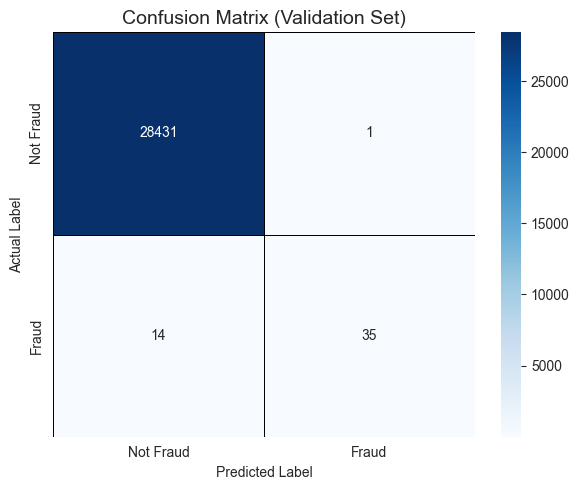

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix properly
cm = confusion_matrix(valid_df[target], preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"],
    linewidths=0.5,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Validation Set)", fontsize=14)
plt.tight_layout()
plt.show()


In [98]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score
)

pred_proba = clf.predict_proba(valid_df[predictors])[:, 1]

print("ROC-AUC:", roc_auc_score(valid_df[target], pred_proba))
print("PR-AUC:", average_precision_score(valid_df[target], pred_proba))

# Default threshold
preds = (pred_proba >= 0.5).astype(int)

print("Fraud Recall:", recall_score(valid_df[target], preds))
print("Fraud Precision:", precision_score(valid_df[target], preds))


ROC-AUC: 0.9363946056756974
PR-AUC: 0.8550913079370349
Fraud Recall: 0.7142857142857143
Fraud Precision: 0.9722222222222222


In [99]:
test_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
75409,56050.0,0.962553,-0.123669,0.191440,1.272528,0.014626,0.376709,0.111713,0.105032,-0.019954,-0.011547,0.940161,1.333377,0.271554,0.181885,-0.803798,-0.437807,-0.127370,-0.406927,0.012627,0.050584,-0.009647,-0.020531,-0.203341,-0.271273,0.656191,-0.321373,0.020455,0.019890,102.99,0
239462,150120.0,0.172024,0.862745,-0.842577,-0.888954,1.379611,0.043337,0.751952,0.175309,-0.044903,-0.624525,-0.138717,-0.437641,-1.146490,-0.633973,-0.725918,0.890388,-0.192071,0.772903,0.462991,-0.017780,-0.373224,-1.017421,-0.033322,-0.548891,-0.354467,0.163690,0.209272,0.060995,1.29,0
201696,133995.0,-0.138404,1.214197,-0.648196,-1.124965,1.184945,-1.679063,1.901974,-0.689442,-0.053799,0.038796,-0.759300,-0.226155,-0.404501,0.467816,-0.079576,-0.827132,-0.449564,-0.507352,-0.233166,0.102049,0.168193,0.948825,-0.278075,0.035058,-0.304206,0.067616,0.340771,0.104143,0.31,0
185519,126706.0,-1.208556,1.641784,-2.903438,-2.315568,3.144686,2.647060,0.720753,1.058941,-0.022217,0.444132,-0.194128,0.047253,-0.406355,0.930963,0.271804,-0.721211,-0.381033,-0.529142,-0.349226,0.291348,0.130332,0.764913,-0.131375,0.741982,-0.119884,0.071818,0.164597,-0.146469,0.08,0
131327,79559.0,-0.855970,0.512196,0.283505,-0.150016,0.322476,-0.832388,0.529440,0.223003,-0.853394,-0.635242,-1.149166,-0.034606,0.495890,0.638984,0.965324,0.111559,-0.107166,-0.424938,1.371042,0.261656,-0.247048,-1.142662,0.231625,-0.440926,-0.681769,0.663068,-0.078005,0.006576,69.42,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192994,129949.0,-1.061990,0.567242,1.974099,-0.054787,0.707858,0.437235,0.607381,0.377091,-0.077025,-0.998065,0.084207,0.600249,-1.097287,-0.088482,-2.390118,-0.017624,-0.482739,-0.180249,-0.040715,-0.118428,-0.457307,-1.381918,-0.098057,0.655003,0.532772,-1.120479,0.036595,0.066526,24.94,0
108771,71065.0,1.132988,-0.104433,1.207720,1.226110,-0.880601,0.140302,-0.715398,0.280554,0.952589,-0.151650,-0.659568,-0.209013,-1.216804,0.040282,1.016721,0.039317,-0.053821,-0.219156,-0.711450,-0.256284,0.002332,0.143876,0.046891,0.045576,0.276552,-0.365626,0.078574,0.031639,1.00,0
132133,79867.0,-0.808640,1.072073,1.664690,-0.691667,0.711321,0.008134,0.831335,0.144671,-1.027914,-0.976564,1.491148,1.030002,0.916597,-0.404030,-0.008300,0.586812,-0.362515,-0.156938,-0.643674,-0.003095,-0.163695,-0.552942,-0.210904,-0.335261,0.196877,0.039012,0.008660,0.058008,9.99,0
85825,60955.0,-0.989250,0.651069,-0.998413,-1.408951,2.812663,3.547332,-0.818144,-1.795880,-0.592282,-1.081268,-0.728245,0.109116,-0.516761,0.623179,-0.563859,0.330387,-0.676533,-0.023035,-0.224102,0.504656,-1.251679,0.473073,0.358968,1.024587,-0.263910,0.288005,0.122177,0.164521,1.00,0


In [100]:
from sklearn.ensemble import AdaBoostClassifier

clf = AdaBoostClassifier(
    random_state=RANDOM_STATE,
    learning_rate=0.8,
    n_estimators=NUM_ESTIMATORS
)

In [101]:
clf.fit(train_df[predictors], train_df[target])

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [102]:
preds = clf.predict(valid_df[predictors])

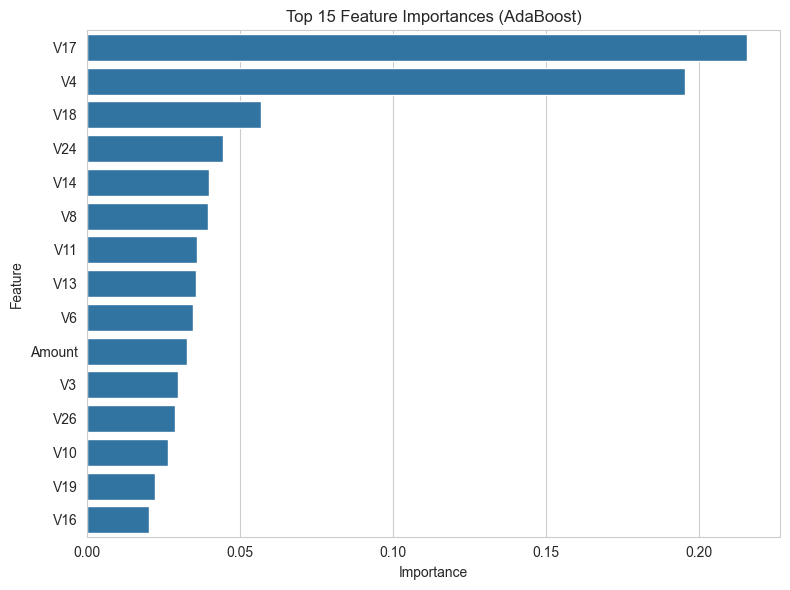

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tmp = pd.DataFrame({
    "Feature": predictors,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=tmp.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances (AdaBoost)")
plt.tight_layout()
plt.show()

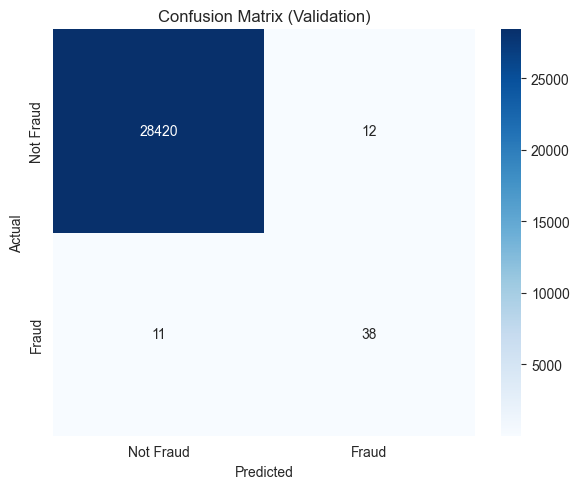

In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(valid_df[target], preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation)")
plt.tight_layout()
plt.show()


In [105]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# Get probabilities
pred_proba = clf.predict_proba(valid_df[predictors])[:, 1]

print("ROC-AUC:", roc_auc_score(valid_df[target], pred_proba))
print("PR-AUC:", average_precision_score(valid_df[target], pred_proba))

print("\nClassification Report:\n")
print(classification_report(valid_df[target], preds))

ROC-AUC: 0.9719929685436358
PR-AUC: 0.7218147575549602

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.76      0.78      0.77        49

    accuracy                           1.00     28481
   macro avg       0.88      0.89      0.88     28481
weighted avg       1.00      1.00      1.00     28481



In [106]:
from sklearn.metrics import roc_auc_score

# Get probability scores for positive class
probs = clf.predict_proba(valid_df[predictors])[:, 1]

# Compute ROC-AUC properly
roc_auc = roc_auc_score(valid_df[target].values, probs)

print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.9719929685436358


In [107]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [108]:
clf = CatBoostClassifier(
    iterations=500,
    learning_rate=0.02,
    depth=12,
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    bagging_temperature=0.2,
    od_type='Iter',
    od_wait=100,
    verbose=VERBOSE_EVAL
)


In [109]:
clf.fit(
    train_df[predictors],
    train_df[target],
    eval_set=(valid_df[predictors], valid_df[target]),
    use_best_model=True
)

0:	test: 0.9230168	best: 0.9230168 (0)	total: 335ms	remaining: 2m 47s
50:	test: 0.9718067	best: 0.9723178 (46)	total: 17.7s	remaining: 2m 36s
100:	test: 0.9701622	best: 0.9723178 (46)	total: 34.4s	remaining: 2m 15s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9723177678
bestIteration = 46

Shrink model to first 47 iterations.


CatBoostClassifier(bagging_temperature=0.2, depth=12, eval_metric='AUC', iterations=500, learning_rate=0.02, od_type='Iter', od_wait=100, random_seed=42, verbose=50)

In [110]:
preds = clf.predict(valid_df[predictors])

In [111]:
probs = clf.predict_proba(valid_df[predictors])[:, 1]

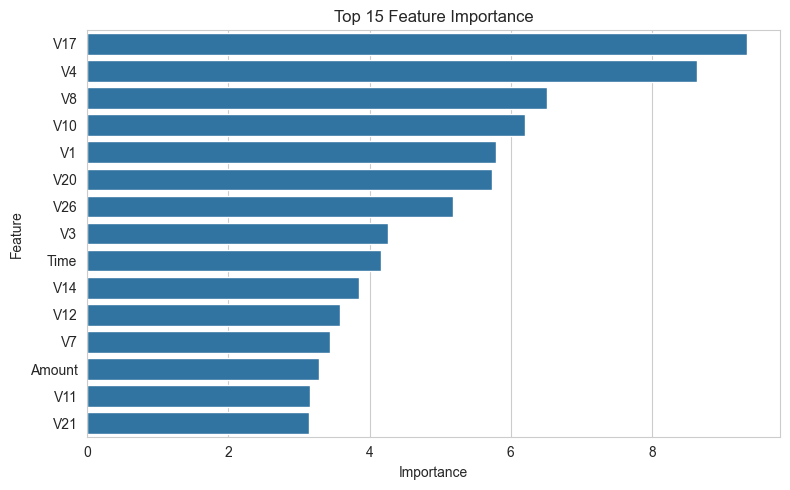

In [112]:
feature_importance = clf.get_feature_importance()

tmp = pd.DataFrame({
    'Feature': predictors,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=tmp.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

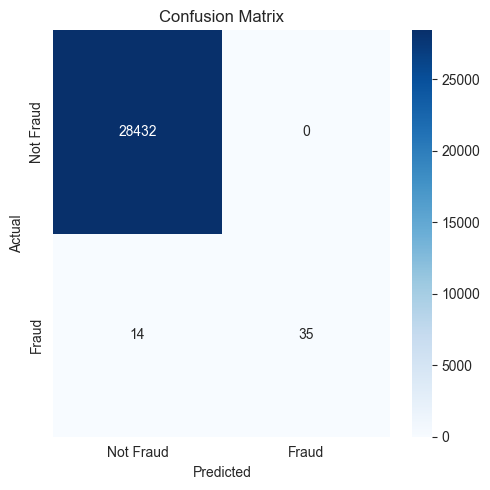

In [113]:
cm = pd.crosstab(
    valid_df[target],
    preds,
    rownames=['Actual'],
    colnames=['Predicted']
)

plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Fraud','Fraud'],
    yticklabels=['Not Fraud','Fraud']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [114]:
roc_auc = roc_auc_score(valid_df[target], probs)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9723177678499649


In [115]:
print(classification_report(valid_df[target], preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       1.00      0.71      0.83        49

    accuracy                           1.00     28481
   macro avg       1.00      0.86      0.92     28481
weighted avg       1.00      1.00      1.00     28481



In [116]:
import xgboost as xgb
# Prepare the train, validation and test DMatrix
dtrain = xgb.DMatrix(train_df[predictors], label=train_df[target])
dvalid = xgb.DMatrix(valid_df[predictors], label=valid_df[target])
dtest  = xgb.DMatrix(test_df[predictors],  label=test_df[target])

# Handle class imbalance (important for fraud detection)
pos = train_df[target].sum()
neg = len(train_df) - pos
scale_pos_weight = neg / pos if pos > 0 else 1

# What to monitor
watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Set XGBoost parameters (clean + updated)
params = {
    "objective": "binary:logistic",
    "learning_rate": 0.039,      # replaces 'eta'
    "max_depth": 2,
    "subsample": 0.8,
    "colsample_bytree": 0.9,
    "eval_metric": "auc",
    "seed": RANDOM_STATE,        # correct randomness control
    "verbosity": 1,              # replaces 'silent'
    "scale_pos_weight": scale_pos_weight
}


In [117]:
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=MAX_ROUNDS,
    evals=watchlist,                     # use keyword argument
    early_stopping_rounds=EARLY_STOP,
    verbose_eval=VERBOSE_EVAL
)

print("Best iteration:", model.best_iteration)
print("Best validation AUC:", model.best_score)


[0]	train-auc:0.94995	valid-auc:0.93771
[50]	train-auc:0.98898	valid-auc:0.95760
[100]	train-auc:0.99387	valid-auc:0.96645
[150]	train-auc:0.99618	valid-auc:0.97211
[200]	train-auc:0.99756	valid-auc:0.97115
Best iteration: 150
Best validation AUC: 0.972106020235894


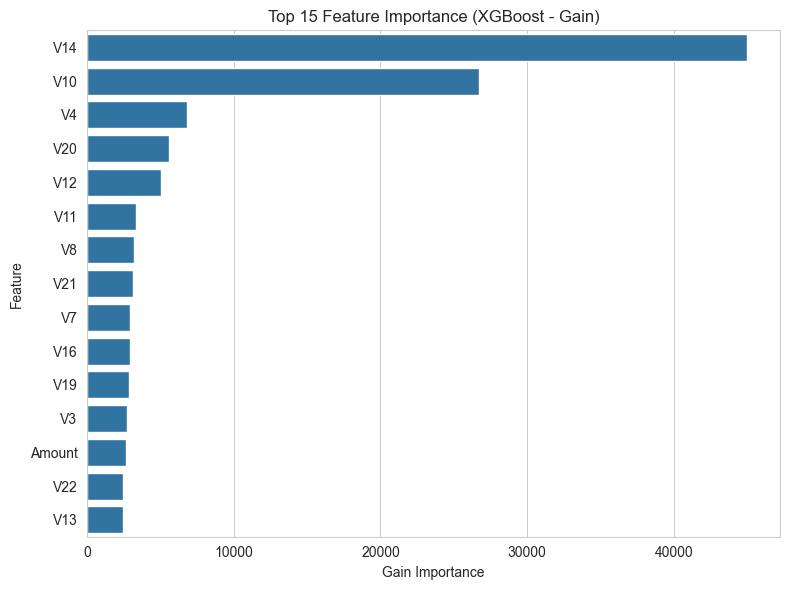

In [118]:
# Get feature importance using 'gain' (more meaningful than default 'weight')
importance_dict = model.get_score(importance_type="gain")

# Convert to DataFrame
importance_df = (
    pd.DataFrame(
        importance_dict.items(),
        columns=["Feature", "Importance"]
    )
    .sort_values(by="Importance", ascending=False)
)

# If features appear as f0, f1... map them back to real column names
if importance_df["Feature"].str.startswith("f").all():
    feature_mapping = {f"f{i}": col for i, col in enumerate(predictors)}
    importance_df["Feature"] = importance_df["Feature"].map(feature_mapping)

# Plot top 15 important features
plt.figure(figsize=(8,6))
sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance (XGBoost - Gain)")
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [119]:
# Predict probabilities using best iteration only
probs_test = model.predict(
    dtest,
    iteration_range=(0, model.best_iteration + 1)
)

# Convert to binary predictions
preds_test = (probs_test >= 0.5).astype(int)


In [120]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    test_df[target].values,
    probs_test   # NOT preds_test
)

print("Test ROC-AUC:", roc_auc)


Test ROC-AUC: 0.9792616540144476


In [121]:
from sklearn.metrics import classification_report

# Predict probabilities
probs_valid = model.predict(
    dvalid,
    iteration_range=(0, model.best_iteration + 1)
)

# Convert to binary labels
preds_valid = (probs_valid >= 0.5).astype(int)

# Classification report
print(classification_report(valid_df[target], preds_valid))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99     28432
           1       0.07      0.86      0.12        49

    accuracy                           0.98     28481
   macro avg       0.53      0.92      0.56     28481
weighted avg       1.00      0.98      0.99     28481



In [136]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(
    boosting_type="gbdt",
    objective="binary",
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    n_estimators=1000,
    random_state=42
)

lgb_clf.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="auc"
)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [123]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X = train_df[predictors]
y = train_df[target]

X_test = test_df[predictors]
y_test = test_df[target]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))


In [124]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_valid, label=y_valid)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        valid_sets=[dvalid],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    oof_preds[valid_idx] = model.predict(
        X_valid,
        num_iteration=model.best_iteration
    )

    test_preds += model.predict(
        X_test,
        num_iteration=model.best_iteration
    ) / 5


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[288]	valid_0's auc: 0.996043
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[26]	valid_0's auc: 0.964455
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[19]	valid_0's auc: 0.943546
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[952]	valid_0's auc: 0.99651
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[242]	valid_0's auc: 0.981417


<Figure size 800x500 with 0 Axes>

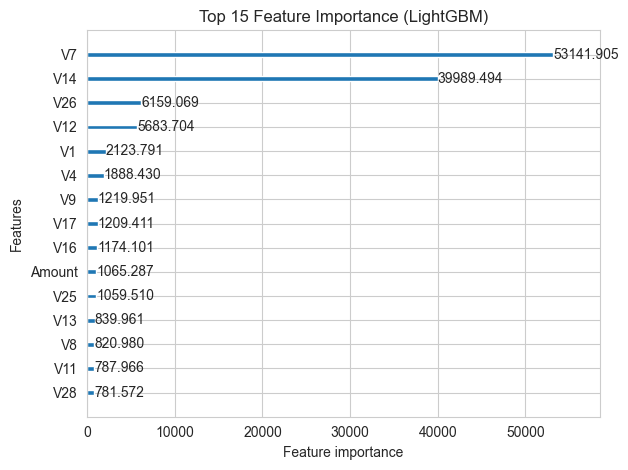

In [125]:
# Plot LightGBM feature importance (gain-based)

plt.figure(figsize=(8, 5))

lgb.plot_importance(
    model,
    importance_type="gain",
    max_num_features=15
)

plt.title("Top 15 Feature Importance (LightGBM)")
plt.tight_layout()
plt.show()

In [126]:
cv_auc = roc_auc_score(y, oof_preds)
test_auc = roc_auc_score(y_test, test_preds)

print("5-Fold CV AUC:", cv_auc)
print("Test AUC:", test_auc)

5-Fold CV AUC: 0.9451024114146792
Test AUC: 0.9742170362799031


In [127]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, test_preds)
print("Test PR-AUC:", pr_auc)

Test PR-AUC: 0.8875217044382995


In [128]:
from sklearn.metrics import classification_report, confusion_matrix

preds_test = (test_preds >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds_test))

print("\nClassification Report:")
print(classification_report(y_test, preds_test))


Confusion Matrix:
[[28425     7]
 [    7    42]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.86      0.86      0.86        49

    accuracy                           1.00     28481
   macro avg       0.93      0.93      0.93     28481
weighted avg       1.00      1.00      1.00     28481



In [129]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores = []

for t in thresholds:
    preds = (test_preds >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best Threshold:", best_threshold)
print("Best F1 Score:", best_f1)


Best Threshold: 0.19
Best F1 Score: 0.88


In [130]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresh = precision_recall_curve(y_test, test_preds)

target_precision = 0.90

valid_idx = np.where(precision >= target_precision)[0]

if len(valid_idx) > 0:
    best_recall = recall[valid_idx].max()
    print("Max Recall at Precision >= 90%:", best_recall)
else:
    print("Model cannot reach 90% precision.")


Max Recall at Precision >= 90%: 0.7959183673469388


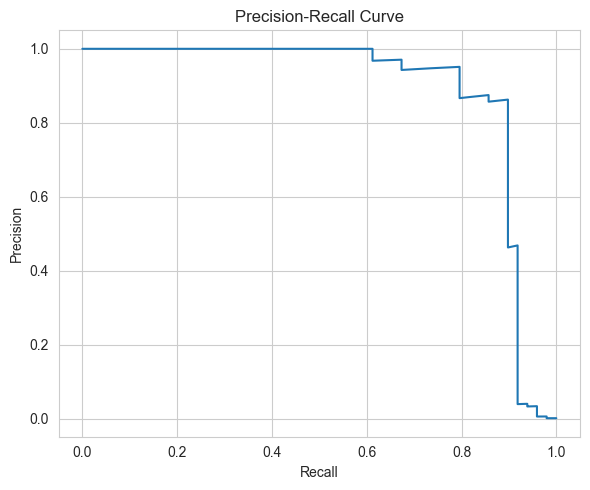

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [132]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score
)
import numpy as np

# Put all probability predictions here
models_preds = {
    "LightGBM": test_preds,              # your CV averaged preds
    # "XGBoost": probs_test_xgb,
    # "RandomForest": probs_test_rf,
    # "CatBoost": probs_test_cat
}

print("="*60)

for name, probs in models_preds.items():

    print(f"\nModel: {name}")
    print("-"*60)

    # ROC-AUC
    roc = roc_auc_score(y_test, probs)

    # PR-AUC
    pr = average_precision_score(y_test, probs)

    # Best F1 threshold
    thresholds = np.arange(0.01, 0.99, 0.01)
    f1_scores = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    # Recall at 90% precision
    precision, recall, thresh = precision_recall_curve(y_test, probs)
    target_precision = 0.90
    valid_idx = np.where(precision >= target_precision)[0]

    if len(valid_idx) > 0:
        recall_at_90 = recall[valid_idx].max()
    else:
        recall_at_90 = 0.0

    print(f"ROC-AUC: {roc:.6f}")
    print(f"PR-AUC: {pr:.6f}")
    print(f"Best F1: {best_f1:.6f}")
    print(f"Best Threshold: {best_threshold:.2f}")
    print(f"Recall @ 90% Precision: {recall_at_90:.6f}")

print("\n" + "="*60)



Model: LightGBM
------------------------------------------------------------
ROC-AUC: 0.974217
PR-AUC: 0.887522
Best F1: 0.880000
Best Threshold: 0.19
Recall @ 90% Precision: 0.795918



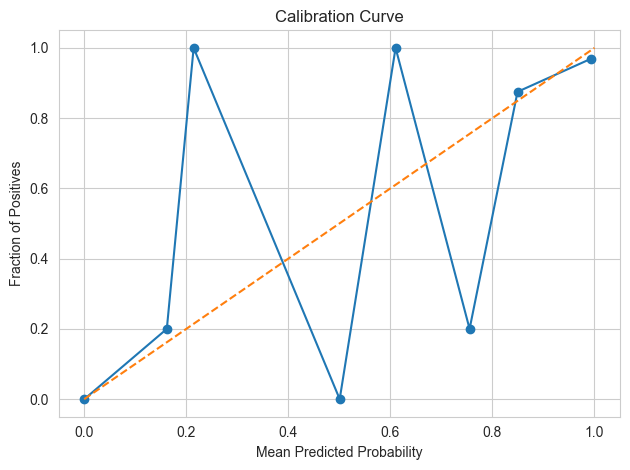

In [133]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, test_preds, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.show()


In [138]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    lgb_clf,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train, y_train)

calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]


In [139]:
calibrated_probs

array([7.76776250e-04, 7.80757335e-05, 1.14056643e-04, ...,
       7.80757335e-05, 1.14056643e-04, 8.93255928e-05])

FINAL MODEL EVALUATION

Class Positive Rate: 0.001720
Mean Predicted Probability: 0.001859

--- Performance ---
ROC-AUC: 0.990121
PR-AUC: 0.904498
Best F1: 0.903226
Best Threshold: 0.50
Recall @ 90% Precision: 0.857143

--- Confusion Matrix (Best Threshold) ---
[[28430     2]
 [    7    42]]

--- Probability Distribution ---
Min: 0.000078
Max: 0.974359
Std: 0.035559


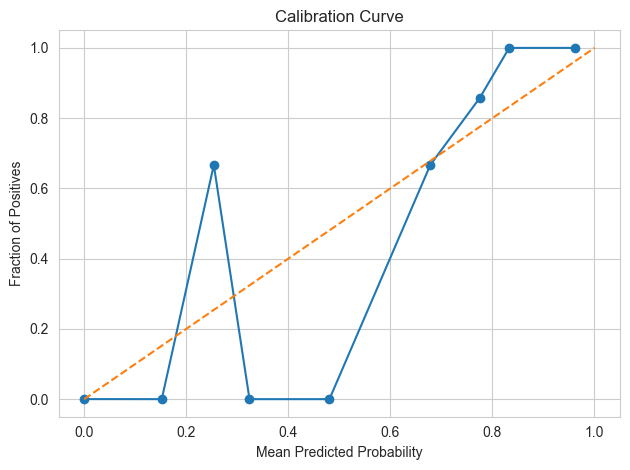

In [140]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    f1_score,
    confusion_matrix
)
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

probs = calibrated_probs  # <<< DO NOT CHANGE

print("="*70)
print("FINAL MODEL EVALUATION")
print("="*70)

# ------------------------------------------------------------------
# Basic Stats
# ------------------------------------------------------------------
pos_rate = y_test.mean()
print(f"\nClass Positive Rate: {pos_rate:.6f}")
print(f"Mean Predicted Probability: {probs.mean():.6f}")

# ------------------------------------------------------------------
# Core Metrics
# ------------------------------------------------------------------
roc = roc_auc_score(y_test, probs)
pr = average_precision_score(y_test, probs)

thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

precision, recall, thresh = precision_recall_curve(y_test, probs)
target_precision = 0.90
valid_idx = np.where(precision >= target_precision)[0]

if len(valid_idx) > 0:
    recall_at_90 = recall[valid_idx].max()
else:
    recall_at_90 = 0.0

print("\n--- Performance ---")
print(f"ROC-AUC: {roc:.6f}")
print(f"PR-AUC: {pr:.6f}")
print(f"Best F1: {best_f1:.6f}")
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Recall @ 90% Precision: {recall_at_90:.6f}")

# ------------------------------------------------------------------
# Confusion Matrix at Best Threshold
# ------------------------------------------------------------------
y_pred_opt = (probs >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

print("\n--- Confusion Matrix (Best Threshold) ---")
print(cm)

# ------------------------------------------------------------------
# Probability Distribution
# ------------------------------------------------------------------
print("\n--- Probability Distribution ---")
print(f"Min: {probs.min():.6f}")
print(f"Max: {probs.max():.6f}")
print(f"Std: {probs.std():.6f}")

# ------------------------------------------------------------------
# Calibration Curve
# ------------------------------------------------------------------
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.show()

print("\n" + "="*70)
